In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import optuna
from stable_baselines3 import PPO
from datetime import datetime
import os

# --- CONFIGURATION ---
CONFIG = {
    "WINDOW_SIZE": 60,
    "TX_COST_BPS": 0.0010,
    "RISK_AVERSION": 4.0,
    "SMA_WINDOW": 50,
    "RSI_WINDOW": 14
}

def load_real_data(tickers=None, benchmark='QQQ', start='2015-01-01', end=None):
    """
    V2.1 Loader: Dynamic End Date + Diversified Universe + Safety Checks
    """
    if end is None:
        end = datetime.today().strftime('%Y-%m-%d')

    if tickers is None:
        # V2 Universe: Tech Growth + Uncorrelated Hedges
        tickers = [
            'NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG', # Growth
            'GLD', 'TLT', 'XLE', 'XLP'                           # Defensive
        ]
    
    all_tickers = tickers + [benchmark]
    print(f"Downloading {len(all_tickers)} assets from {start} to {end}...")
    
    # auto_adjust=True handles splits/dividends
    raw_data = yf.download(all_tickers, start=start, end=end, progress=False, auto_adjust=True)
    
    # Handle MultiIndex
    if isinstance(raw_data.columns, pd.MultiIndex):
        try:
            df = raw_data['Close'].copy()
        except KeyError:
            df = raw_data['close'].copy()
    else:
        df = raw_data.copy()

    # Rename Benchmark to 'SPY' (Internal convention for the Env)
    # We map whatever you requested (e.g., QQQ) to 'SPY' so the feature engineer finds it.
    if benchmark in df.columns:
        df = df.rename(columns={benchmark: 'SPY'})
    
    # --- SAFETY CHECK ---
    df = df.ffill()
    # Drop assets with >5% missing data before dropping rows
    valid_cols = df.isnull().mean() < 0.05
    df = df.loc[:, valid_cols]
    df = df.dropna().round(2)
    
    # Reorder
    asset_cols = [t for t in tickers if t in df.columns]
    final_cols = asset_cols + ['SPY']
    
    return df[final_cols]
class FinancialFeatureEngineer:
    def preprocess_data(self, df):
        data = df.copy()
        asset_cols = [c for c in data.columns if c != 'SPY']
        
        # 1. Log Returns
        log_ret = np.log(data[asset_cols] / data[asset_cols].shift(1)).fillna(0)
        
        # 2. Volatility (Z-Score)
        roll_std = log_ret.rolling(20).std()
        norm_vol = (roll_std - roll_std.rolling(252).mean()) / (roll_std.rolling(252).std() + 1e-8)
        
        # 3. RSI
        delta = data[asset_cols].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        norm_rsi = (100 - (100 / (1 + rs)) - 50) / 100 
        
        # 4. Distance from SMA (Trend)
        sma_50 = data[asset_cols].rolling(50).mean()
        dist_sma = (data[asset_cols] / sma_50) - 1.0

        # --- 5. RELATIVE STRENGTH (Alpha) --- [NEW]
        # Asset Performance / Benchmark Performance over 60 days
        asset_cum_ret = data[asset_cols].pct_change(60)
        bench_cum_ret = data['SPY'].pct_change(60)
        # Broadcast benchmark to shape of assets
        # If Asset > Bench, value > 0. If Asset < Bench, value < 0
        rel_strength = asset_cum_ret.sub(bench_cum_ret, axis=0)

        # Cleanup
        norm_vol = norm_vol.fillna(0).clip(-3, 3)
        norm_rsi = norm_rsi.fillna(0)
        dist_sma = dist_sma.fillna(0).clip(-0.5, 0.5)
        rel_strength = rel_strength.fillna(0).clip(-0.5, 0.5)
        
        # Stack 5 Features (Vol, RSI, DistSMA, RelStr, LogRet)
        features = np.stack([
            norm_vol.values, 
            norm_rsi.values, 
            dist_sma.values, # Index 2
            rel_strength.values, # Index 3 (Alpha Signal)
            log_ret.values
        ], axis=-1)
        
        return features, data[asset_cols].values, data['SPY'].values
        
# --- EXECUTION BLOCK ---
df_v2 = load_real_data()
engineer = FinancialFeatureEngineer()
features, prices, benchmark = engineer.preprocess_data(df_v2)

# Split
split = int(len(df_v2) * 0.8)
feat_train, feat_test = features[:split], features[split:]
price_train, price_test = prices[:split], prices[split:]
bench_train, bench_test = benchmark[:split], benchmark[split:]

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
class PortfolioRebalanceEnv(gym.Env):
    def __init__(self, price_data, features_data, benchmark_data, 
                 initial_balance=100_000, lookback_window=60):
        super().__init__()
        self.prices = price_data
        self.features = features_data
        self.benchmark = benchmark_data
        self.n_assets = self.prices.shape[1]
        self.n_features = self.features.shape[2]
        self.lookback_window = lookback_window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.n_assets + 1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-5, high=5, shape=(lookback_window, self.n_assets, self.n_features), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.lookback_window
        self.cash = 100_000.0
        self.shares = np.zeros(self.n_assets)
        self.portfolio_value = 100_000.0
        self.history_nav = [100_000.0]
        return self._get_obs(), {}

    def step(self, action):
        exp_action = np.exp(action)
        weights = exp_action / np.sum(exp_action)
        
        current_prices = self.prices[self.current_step]
        target_val = self.portfolio_value * weights[:-1]
        current_holdings = self.shares * current_prices
        cost = np.sum(np.abs(target_val - current_holdings)) * CONFIG["TX_COST_BPS"]
        
        self.cash = (self.portfolio_value * weights[-1]) - cost
        self.shares = target_val / current_prices
        
        daily_ret = []
        steps = min(20, len(self.prices) - self.current_step - 1)
        for _ in range(steps):
            self.current_step += 1
            val = self.cash + np.sum(self.shares * self.prices[self.current_step])
            daily_ret.append(np.log(val / self.history_nav[-1]))
            self.history_nav.append(val)
            
        self.portfolio_value = self.history_nav[-1]
        
        # Dynamic Reward
        bench_slice = self.benchmark[self.current_step-20:self.current_step]
        mkt_vol = np.std(bench_slice) if len(bench_slice) > 1 else 0.01
        lam = CONFIG["RISK_AVERSION"] + ((mkt_vol - 0.015)*100 if mkt_vol > 0.015 else 0)
        
        r = np.array(daily_ret)
        downside = np.std(r[r<0]) if len(r[r<0]) > 0 else 0.0
        reward = np.sum(r) - (lam * downside)
        
        return self._get_obs(), reward, self.current_step >= len(self.prices) - 2, False, {}

    def _get_obs(self):
        return self.features[self.current_step-self.lookback_window : self.current_step].astype(np.float32)


In [3]:
class BoardOfDirectorsV3_1:
    def __init__(self, bull_path, bear_path, sniper_path, tickers):
        self.bull = PPO.load(bull_path)
        self.bear = PPO.load(bear_path)
        self.sniper = PPO.load(sniper_path)
        # Identify defensive assets indices to nuke them during rallies
        self.defensive_indices = [i for i, t in enumerate(tickers) if t in ['GLD', 'TLT', 'XLP', 'XLE']]
        
    def _softmax(self, x):
        e = np.exp(x - np.max(x)); return e / e.sum()

    def predict(self, obs, market_vol, avg_trend_strength):
        PANIC_VOL = 0.020      
        STRONG_TREND = 0.02
        
        p1, _ = self.bull.predict(obs, deterministic=True)
        p2, _ = self.bear.predict(obs, deterministic=True)
        p3, _ = self.sniper.predict(obs, deterministic=True)
        wb = self._softmax(p1); wbr = self._softmax(p2); ws = self._softmax(p3)
        
        # --- LOGIC ---
        
        # 1. RALLY (Aggressive Growth)
        if avg_trend_strength > STRONG_TREND:
            # Use 100% Bull Agent
            raw_weights = wb
            
            # FORCE AGGRESSION:
            # A. Set Cash to 0
            raw_weights[-1] = -999.0 # Logits, effectively 0 after softmax
            
            # B. Kill Defensives (GLD, TLT)
            # We want pure Tech/Growth exposure
            for idx in self.defensive_indices:
                raw_weights[idx] = -999.0
            
            # Re-Softmax to normalize
            final_weights = self._softmax(raw_weights)
            return final_weights, "RALLY (Max Aggression)"
            
        # 2. CRASH
        elif market_vol > PANIC_VOL:
            # Same Logic: Cash is King
            cash_only = np.zeros_like(wb); cash_only[-1] = 1.0
            return cash_only, "CRASH"
            
        # 3. NORMAL (Choppy/Sideways)
        else:
            # Here we keep the hedges
            return (0.6 * wb) + (0.4 * ws), "NORMAL"

 

In [4]:
class V3LoggingBacktester:
    def __init__(self, board, env, threshold=0.05):
        self.board = board
        self.env = env
        self.threshold = threshold
        self.tx_cost_bps = 0.0010
        
    def run(self):
        cash = 100_000.0
        shares = np.zeros(self.env.n_assets)
        history = []
        
        curr = self.env.lookback_window
        end = len(self.env.prices) - 22
        
        while curr < end:
            # 1. Calculate Signals
            b_slice = self.env.benchmark[curr-5:curr]
            vol = pd.Series(b_slice).pct_change().std() if len(b_slice)>1 else 0.01
            if np.isnan(vol): vol = 0.01
            
            obs = self.env.features[curr-60:curr]
            latest_feats = obs[-1]
            # Index 3 is Trend Strength (Dist from EMA)
            avg_trend = np.mean(latest_feats[:, 3]) 
            
            # 2. Get Decision
            target_w, regime = self.board.predict(obs, vol, avg_trend)
            
            # 3. Execute
            p = self.env.prices[curr]
            val = cash + np.sum(shares * p)
            
            if val > 0: cw = np.append((shares*p)/val, cash/val)
            else: cw = np.zeros_like(target_w); cw[-1] = 1.0
            
            # Lower inertia for critical regime changes
            act_thresh = 0.01 if regime in ["CRASH", "RALLY (Vol Ignored)"] else self.threshold
            
            if np.sum(np.abs(target_w - cw)) > act_thresh:
                t_val = val * target_w
                cost = np.sum(np.abs(t_val[:-1] - (shares*p))) * self.tx_cost_bps
                cash = t_val[-1] - cost
                shares = t_val[:-1] / p
                curr_w = target_w # For logging
            else:
                curr_w = cw # We didn't trade, so we kept current weights
                
            # 4. Simulate & LOG EVERYTHING
            for t in range(20):
                idx = curr + t + 1
                nav = cash + np.sum(shares * self.env.prices[idx])
                
                history.append({
                    'step': idx, 
                    'nav': nav, 
                    'regime': regime,
                    'volatility': vol,          # Logged
                    'trend_strength': avg_trend,# Logged
                    'weights': curr_w           # Logged
                })
            curr += 20
            
        return pd.DataFrame(history)

Training Specialists...
Agents Saved.


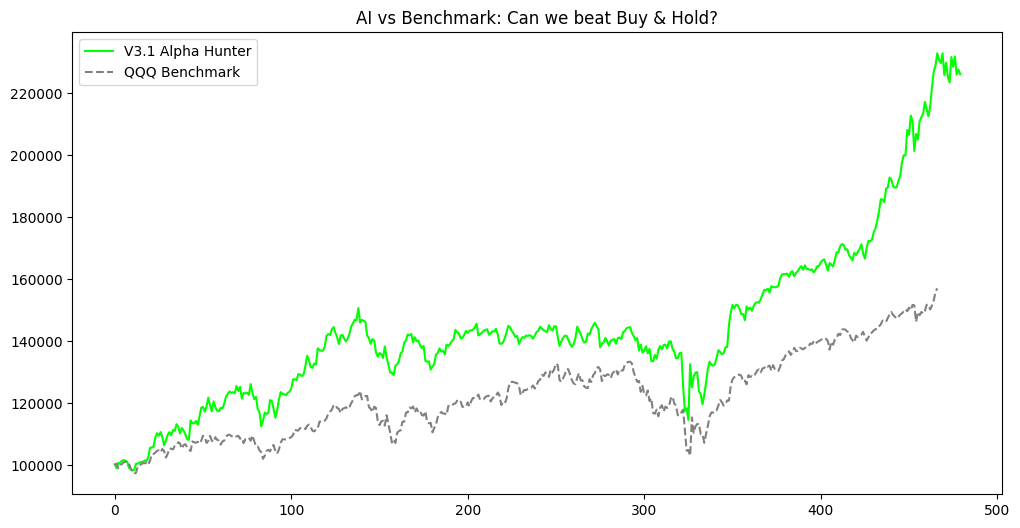

AI Return: 126.17%
QQQ Return: 57.08%


In [5]:
# 1. Setup Data & Features (V3.1)
df_v2 = load_real_data() # Uses V2 Tickers
engineer = FinancialFeatureEngineer() # Uses V3.1 Features (Rel Strength)
features, prices, benchmark = engineer.preprocess_data(df_v2)

# Split
split = int(len(df_v2) * 0.8)
f_train, f_test = features[:split], features[split:]
p_train, p_test = prices[:split], prices[split:]
b_train, b_test = benchmark[:split], benchmark[split:]

# 2. Train (Required due to feature change)
print("Training Specialists...")
train_env = PortfolioRebalanceEnv(price_train, feat_train, bench_train)

# Bull
model_bull = PPO("MlpPolicy", train_env, verbose=0)
model_bull.learn(total_timesteps=30_000)
model_bull.save("agent_bull")

# Bear (FIXED: Added .learn())
model_bear = PPO("MlpPolicy", train_env, verbose=0, ent_coef=0.05)
model_bear.learn(total_timesteps=30_000) 
model_bear.save("agent_bear")

# Sniper
model_sniper = PPO("MlpPolicy", train_env, verbose=0)
model_sniper.learn(total_timesteps=30_000)
model_sniper.save("agent_sniper")
print("Agents Saved.")

# 3. Run V3.1 Logic
# Get tickers list for the defensive filter
TICKER_LIST = ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG', 'GLD', 'TLT', 'XLE', 'XLP']

board_alpha = BoardOfDirectorsV3_1("agent_bull", "agent_bear", "agent_sniper", TICKER_LIST)
test_env = PortfolioRebalanceEnv(p_test, f_test, b_test)

# Reuse V3LoggingBacktester from previous step (it's compatible)
logger = V3LoggingBacktester(board_alpha, test_env, threshold=0.05)
results = logger.run()

# 4. Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(results['nav'], color='lime', label='V3.1 Alpha Hunter')

# Add QQQ Benchmark for comparison
# Align dates
qqq_prices = test_env.benchmark[test_env.lookback_window : len(test_env.benchmark)-22]
qqq_nav = (qqq_prices / qqq_prices[0]) * 100000
plt.plot(qqq_nav, color='gray', linestyle='--', label='QQQ Benchmark')

plt.title("AI vs Benchmark: Can we beat Buy & Hold?")
plt.legend()
plt.show()

# Final Score
ai_ret = (results['nav'].iloc[-1] / 100000) - 1
qqq_ret = (qqq_nav[-1] / 100000) - 1
print(f"AI Return: {ai_ret:.2%}")
print(f"QQQ Return: {qqq_ret:.2%}")

In [6]:
           
# --- OPTIMIZATION ENGINE (SPEED HACK) ---
# Pre-compute weights
indices = range(60, len(price_train)-22, 20)
w_bull, w_bear, w_sniper = [], [], []
signals = []
board = BoardOfDirectorsV3_1("agent_bull", "agent_bear", "agent_sniper", TICKER_LIST)

for i in indices:
    obs = train_env.features[i-60:i]
    p1, _ = board.bull.predict(obs, deterministic=True)
    p2, _ = board.bear.predict(obs, deterministic=True)
    p3, _ = board.sniper.predict(obs, deterministic=True)
    w_bull.append(p1); w_bear.append(p2); w_sniper.append(p3)
    
    # Pre-calc V2 Signals
    b_short = train_env.benchmark[i-5:i]
    vol = pd.Series(b_short).pct_change().std() if len(b_short)>1 else 0.01
    
    # RSI is at Index 1
    raw_rsi = (obs[-1,:,1] * 100) + 50
    avg_rsi = np.mean(raw_rsi)
    
    b_hist = train_env.benchmark[i-50:i]
    sma = np.mean(b_hist) if len(b_hist)>0 else 0
    price_up = train_env.benchmark[i] > sma
    signals.append((vol, avg_rsi, price_up))

w_bull = np.array(w_bull); w_bear = np.array(w_bear); w_sniper = np.array(w_sniper)

class TurboLogicEngine:
    def __init__(self, prices, wb, wbr, ws, sigs, idxs, n_assets):
        self.prices = prices; self.wb = wb; self.wbr = wbr; self.ws = ws
        self.sigs = sigs; self.idxs = idxs; self.n_assets = n_assets
        
    def _softmax(self, x):
        e = np.exp(x - np.max(x)); return e / e.sum()

    def run(self, p_vol, thresh, re_alloc):
        cash = 100_000.0
        shares = np.zeros(self.n_assets)
        hist = []
        
        for ptr, i in enumerate(self.idxs):
            vol, rsi, price_up = self.sigs[ptr]
            wb = self._softmax(self.wb[ptr])
            ws = self._softmax(self.ws[ptr])
            wbr = self._softmax(self.wbr[ptr])
            
            reg = "GROWTH"
            if vol > p_vol:
                if rsi < 30 or price_up:
                    # Re-entry Alloc Optimization
                    aw = ws[:-1] / (np.sum(ws[:-1]) + 1e-9)
                    tw = np.append(aw * re_alloc, (1.0 - re_alloc))
                    reg = "RE-ENTRY"
                else:
                    tw = np.zeros_like(ws); tw[-1] = 1.0
                    reg = "CRASH"
            elif vol > 0.012:
                tw = (0.5*ws) + (0.25*wbr) + (0.25*wb)
                reg = "CHOPPY"
            else:
                tw = (0.7*wb) + (0.3*ws)
            
            # Wrapper
            p = self.prices[i]
            val = cash + np.sum(shares * p)
            if val > 0: cw = np.append((shares*p)/val, cash/val)
            else: cw = np.zeros_like(tw); cw[-1] = 1.0
            
            act_thresh = 0.01 if reg in ["CRASH", "RE-ENTRY"] else thresh
            if np.sum(np.abs(tw - cw)) > act_thresh:
                t_val = val * tw
                cost = np.sum(np.abs(t_val[:-1] - (shares*p))) * CONFIG["TX_COST_BPS"]
                cash = t_val[-1] - cost
                shares = t_val[:-1] / p
            
            end = min(i+20, len(self.prices))
            m_p = self.prices[i+1:end+1]
            m_nav = cash + np.dot(m_p, shares)
            hist.extend(m_nav)
            
        return np.array(hist)

def objective(trial):
    p_vol = trial.suggest_float("panic_vol", 0.015, 0.035)
    thresh = trial.suggest_float("thresh", 0.02, 0.10)
    re_alloc = trial.suggest_float("reentry_alloc", 0.2, 0.8)
    
    engine = TurboLogicEngine(price_train, w_bull, w_bear, w_sniper, signals, indices, train_env.n_assets)
    nav = engine.run(p_vol, thresh, re_alloc)
    
    if len(nav) == 0: return -100
    ret = (nav[-1]/nav[0]) - 1
    dd = np.min((nav / np.maximum.accumulate(nav)) - 1)
    if dd < -0.35: return -1.0
    return ret / (abs(dd) + 1e-6)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
BP = study.best_params
print(f"Best: {BP}")


[I 2025-11-29 16:19:08,280] A new study created in memory with name: no-name-026a61de-5758-44cf-9010-7d68713909f5
[I 2025-11-29 16:19:08,285] Trial 0 finished with value: 20.16846764069659 and parameters: {'panic_vol': 0.021494776167095723, 'thresh': 0.06841954314471671, 'reentry_alloc': 0.7702367420095847}. Best is trial 0 with value: 20.16846764069659.
[I 2025-11-29 16:19:08,290] Trial 1 finished with value: 16.73000024817965 and parameters: {'panic_vol': 0.01589415727495912, 'thresh': 0.041094083887633505, 'reentry_alloc': 0.5206617301517251}. Best is trial 0 with value: 20.16846764069659.
[I 2025-11-29 16:19:08,294] Trial 2 finished with value: 18.72081194109645 and parameters: {'panic_vol': 0.023926477321912665, 'thresh': 0.09046927734512578, 'reentry_alloc': 0.6263050971593266}. Best is trial 0 with value: 20.16846764069659.
[I 2025-11-29 16:19:08,300] Trial 3 finished with value: 17.72682373821162 and parameters: {'panic_vol': 0.0248360665395988, 'thresh': 0.08887811282758191, '

Best: {'panic_vol': 0.017442950919178937, 'thresh': 0.0407091994363793, 'reentry_alloc': 0.20130148710359944}


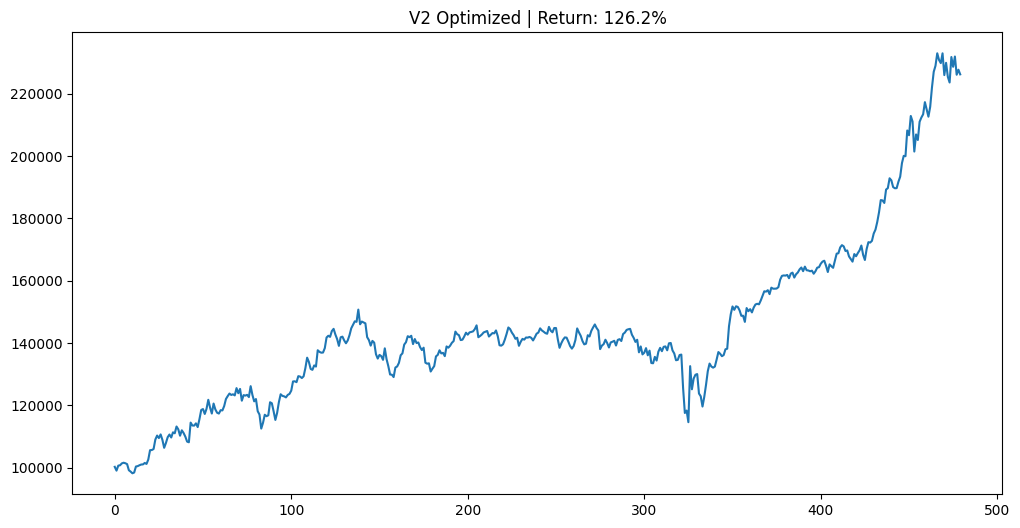

In [7]:

# EXECUTE
test_env = PortfolioRebalanceEnv(price_test, feat_test, bench_test)
tester = V3LoggingBacktester(
    board, test_env, 
    threshold=BP['thresh']
)
res = tester.run()

plt.figure(figsize=(12,6))
plt.plot(res['nav'])
plt.title(f"V2 Optimized | Return: {((res['nav'].iloc[-1]/100000)-1)*100:.1f}%")
plt.show()

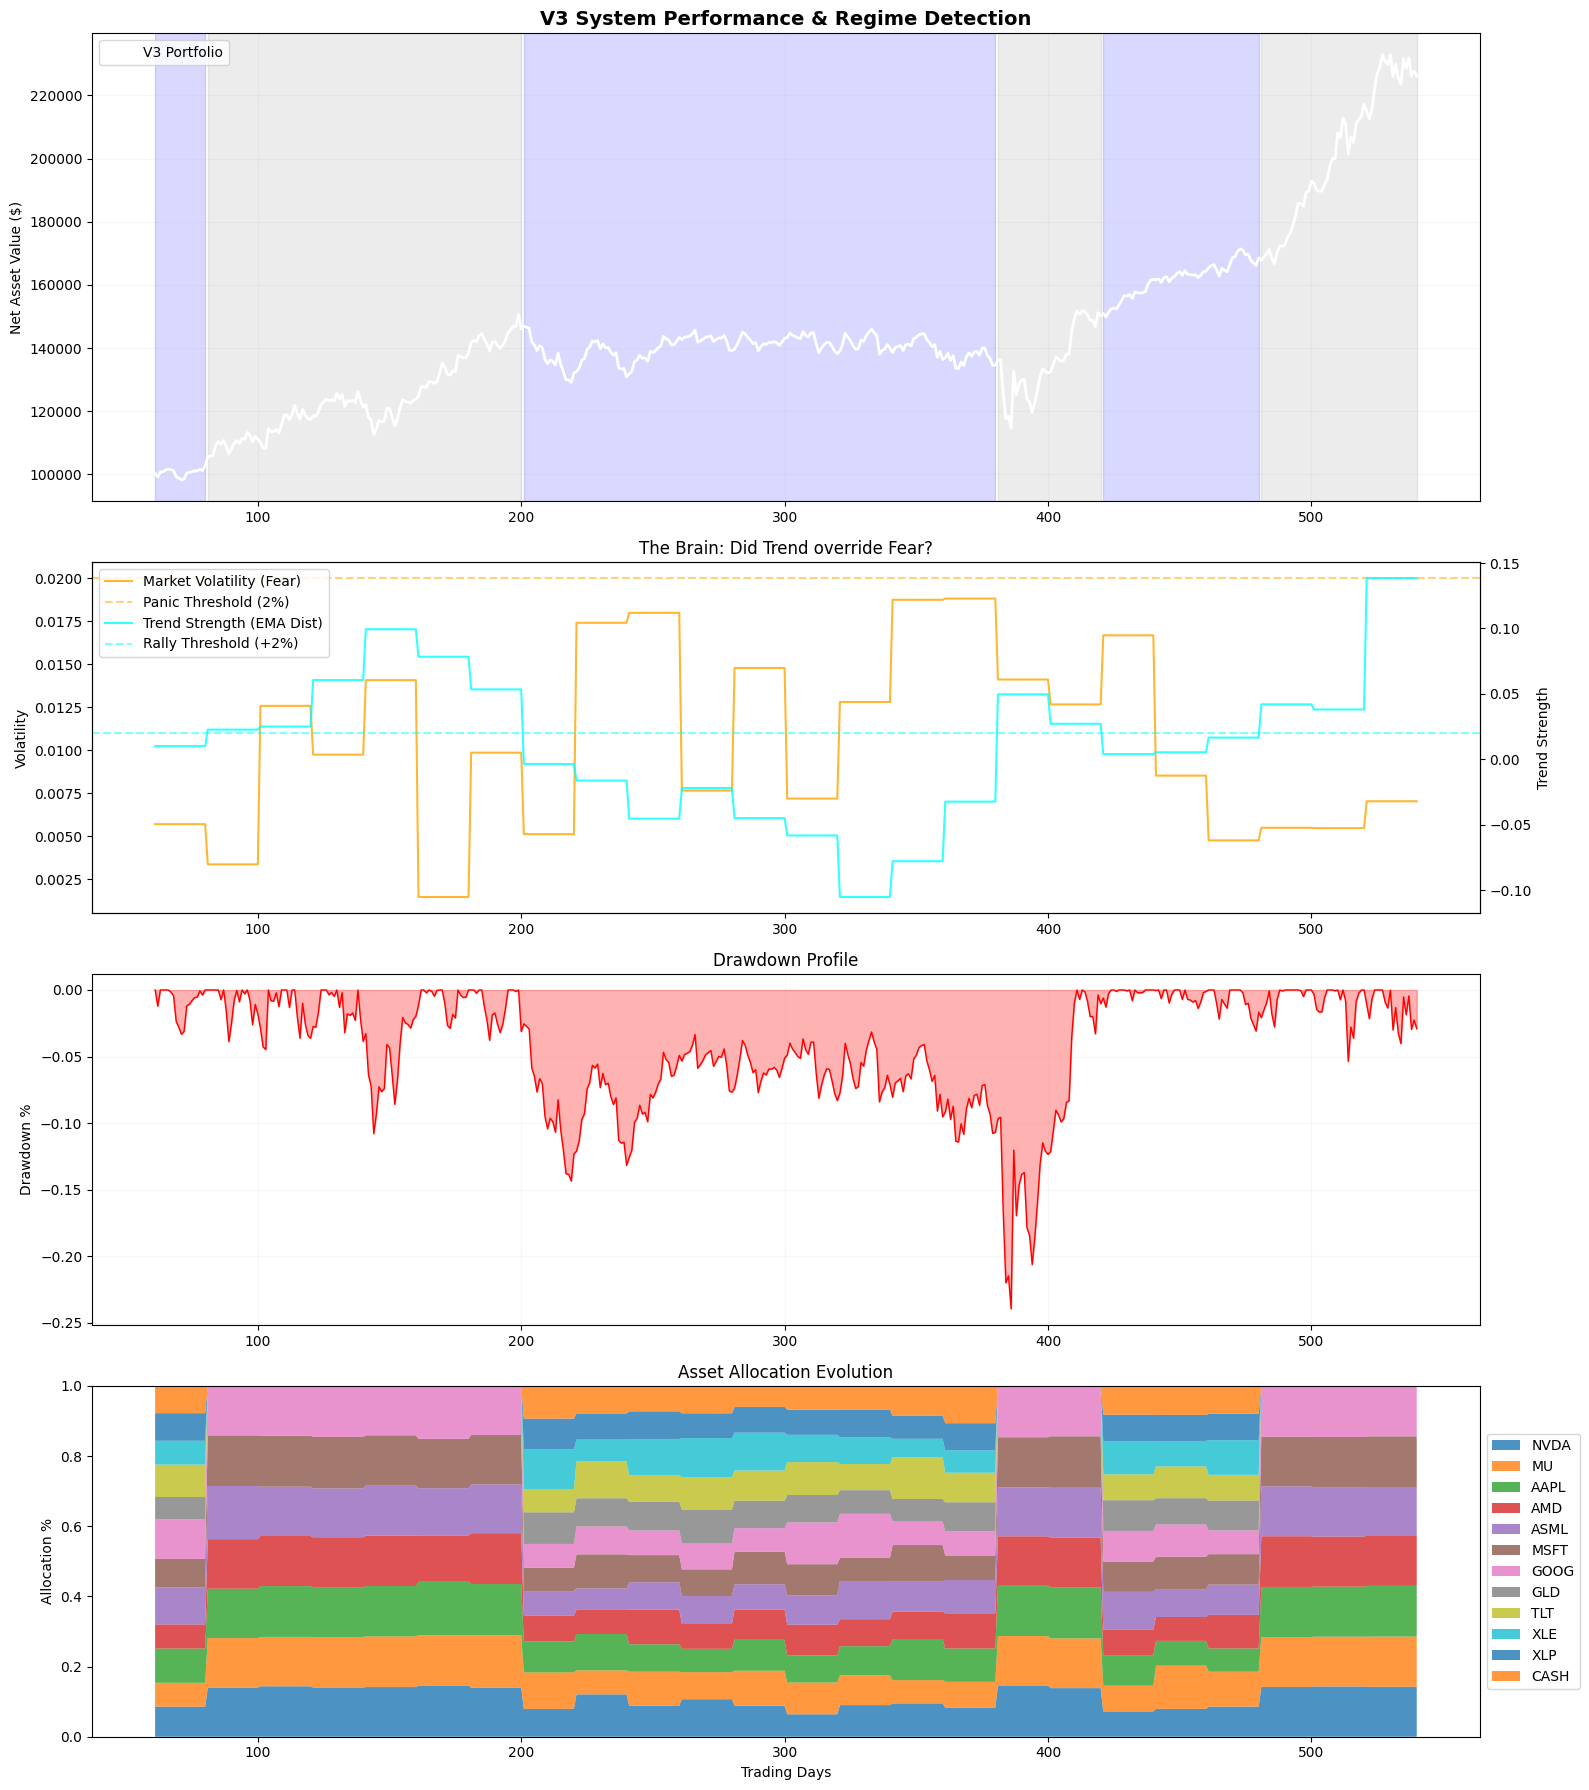

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_mission_control(df, env_tickers):
    # Setup Layout
    fig = plt.figure(figsize=(16, 18))
    gs = fig.add_gridspec(4, 1, height_ratios=[2, 1.5, 1.5, 1.5])
    
    # --- PANEL 1: NAV & Regimes ---
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(df['step'], df['nav'], color='white', linewidth=2, label='V3 Portfolio')
    
    # Color Background by Regime
    regime_colors = {
        'RALLY (Vol Ignored)': 'lime', # The V3 Fix
        'NORMAL': 'blue',
        'CRASH': 'red'
    }
    
    # Efficiently paint background
    # (Grouping by consecutive regimes to avoid 1000s of spans)
    df['regime_group'] = (df['regime'] != df['regime'].shift()).cumsum()
    for _, group in df.groupby('regime_group'):
        start = group['step'].iloc[0]
        end = group['step'].iloc[-1]
        reg = group['regime'].iloc[0]
        col = regime_colors.get(reg, 'gray')
        ax1.axvspan(start, end, color=col, alpha=0.15)
        
    ax1.set_title("V3 System Performance & Regime Detection", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Net Asset Value ($)")
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.1)

    # --- PANEL 2: The V3 Logic (Trend vs Volatility) ---
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    
    # Volatility Line (Fear)
    ax2.plot(df['step'], df['volatility'], color='orange', label='Market Volatility (Fear)', alpha=0.8)
    ax2.axhline(0.020, color='orange', linestyle='--', alpha=0.5, label='Panic Threshold (2%)')
    
    # Trend Line (Greed) - Twin Axis
    ax2b = ax2.twinx()
    ax2b.plot(df['step'], df['trend_strength'], color='cyan', label='Trend Strength (EMA Dist)', alpha=0.8)
    ax2b.axhline(0.02, color='cyan', linestyle='--', alpha=0.5, label='Rally Threshold (+2%)')
    
    # Highlight the "Rally Override" moments
    # Where Vol is High (>2%) BUT Trend is High (>2%)
    override_mask = (df['volatility'] > 0.020) & (df['trend_strength'] > 0.02)
    if override_mask.any():
        ax2.scatter(df[override_mask]['step'], df[override_mask]['volatility'], 
                    color='lime', s=10, label='V3 Logic Triggered', zorder=5)

    ax2.set_title("The Brain: Did Trend override Fear?", fontsize=12)
    ax2.set_ylabel("Volatility")
    ax2b.set_ylabel("Trend Strength")
    
    # Combine legends
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2b.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    # --- PANEL 3: Drawdown ---
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    running_max = df['nav'].cummax()
    dd = (df['nav'] / running_max) - 1
    ax3.fill_between(df['step'], dd, 0, color='red', alpha=0.3)
    ax3.plot(df['step'], dd, color='red', lw=1)
    ax3.set_title("Drawdown Profile", fontsize=12)
    ax3.set_ylabel("Drawdown %")
    ax3.grid(True, alpha=0.1)

    # --- PANEL 4: Allocation Stack ---
    ax4 = fig.add_subplot(gs[3], sharex=ax1)
    
    # Expand weights list into dataframe columns
    weight_matrix = np.vstack(df['weights'].values)
    labels = env_tickers + ['CASH']
    
    # Plot Stack
    ax4.stackplot(df['step'], weight_matrix.T, labels=labels, alpha=0.8)
    
    ax4.set_title("Asset Allocation Evolution", fontsize=12)
    ax4.set_ylabel("Allocation %")
    ax4.set_xlabel("Trading Days")
    ax4.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
    ax4.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

# Run Dashboard
# Note: Pass the list of tickers you used in load_real_data
# If you used the V2 list:
TICKER_LIST = ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG', 'GLD', 'TLT', 'XLE', 'XLP']

plot_mission_control(results, TICKER_LIST)